In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../input/heart-failure-prediction/heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<AxesSubplot:xlabel='Age', ylabel='Cholesterol'>

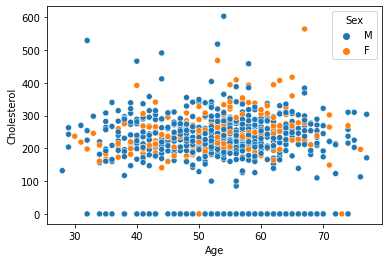

In [6]:
sns.scatterplot(data=df, x='Age',y='Cholesterol',hue='Sex')

<AxesSubplot:xlabel='Age', ylabel='Sex'>

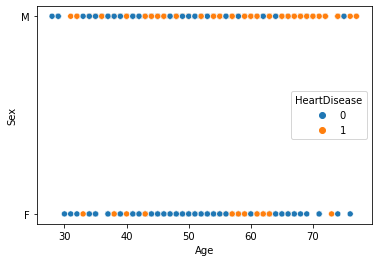

In [7]:
sns.scatterplot(data=df, x='Age',y='Sex',hue='HeartDisease')

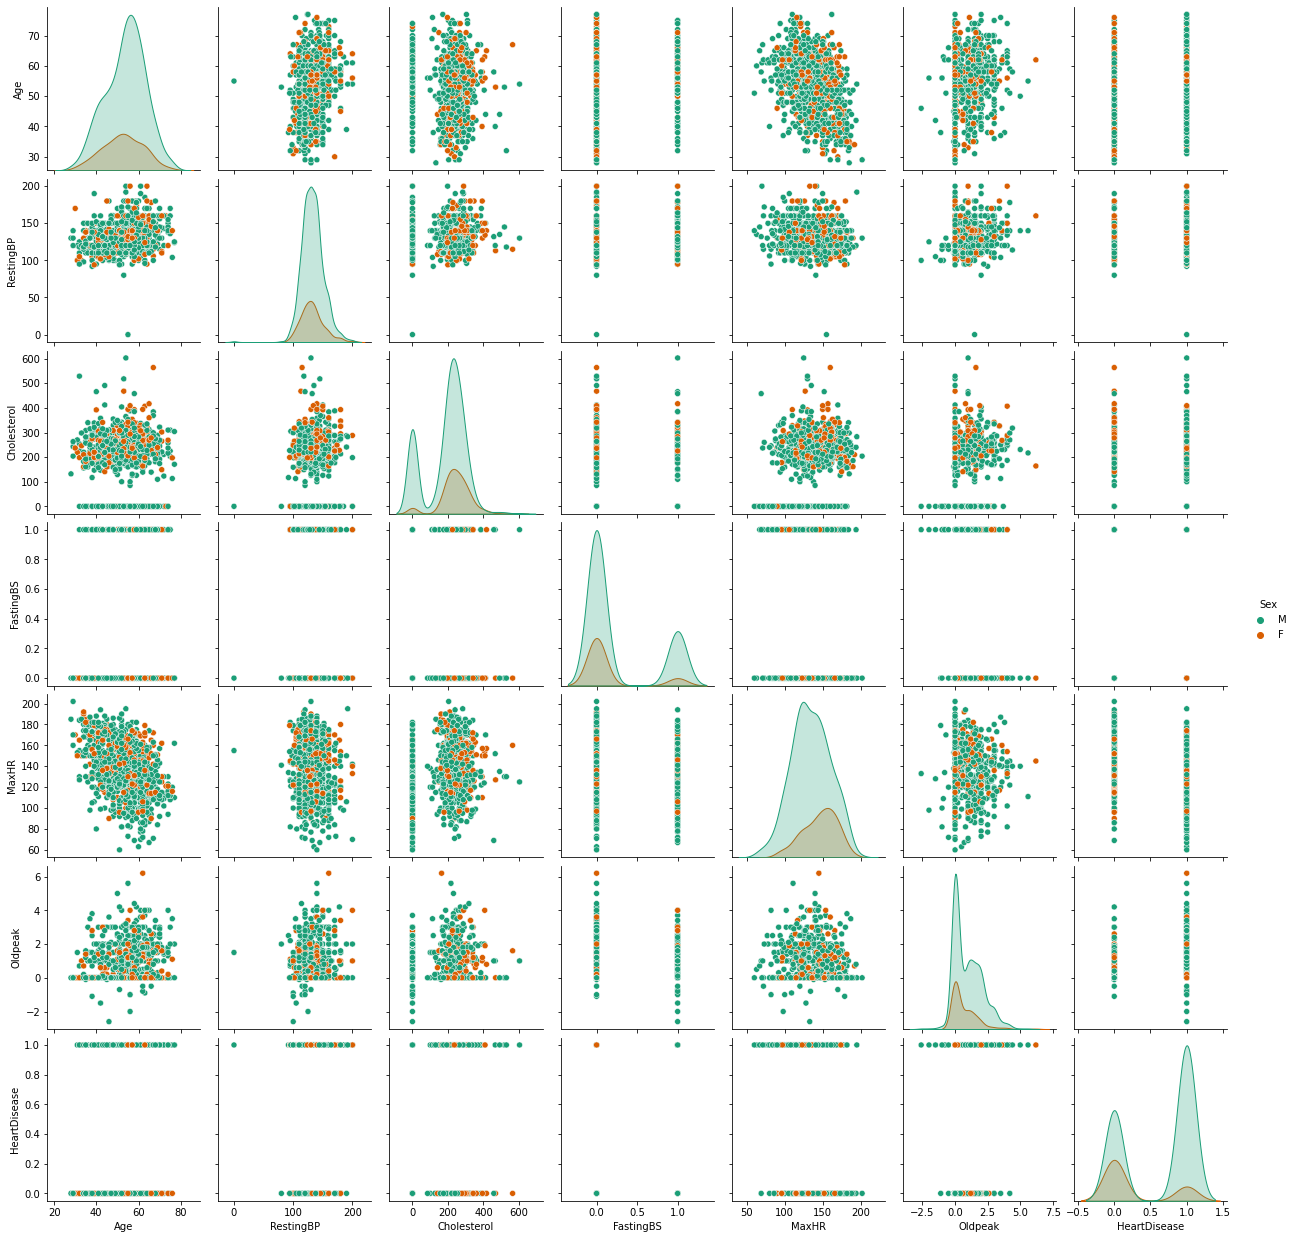

In [8]:
sns.pairplot(df,hue='Sex',palette='Dark2')

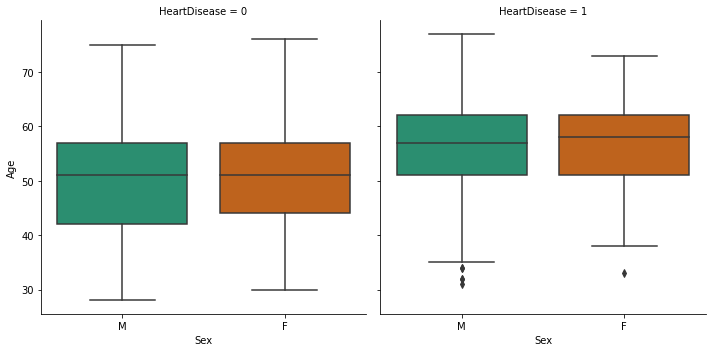

In [9]:
sns.catplot(data=df, x='Sex',y='Age',kind='box',col='HeartDisease',palette='Dark2')

<AxesSubplot:xlabel='Sex', ylabel='count'>

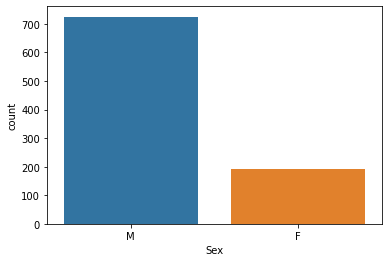

In [10]:
df['Sex'].value_counts()
sns.countplot(data=df, x='Sex')

<AxesSubplot:xlabel='Age', ylabel='count'>

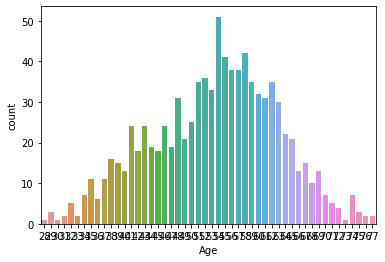

In [11]:
df["Age"].value_counts()
sns.countplot(data=df, x="Age")

In [12]:
pd.get_dummies(df)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1.5,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0.0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,141,3.4,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,115,1.2,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,174,0.0,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


In [13]:
pd.get_dummies(df.drop('Sex',axis=1),drop_first=True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3.4,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1.2,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0.0,1,1,0,0,0,0,0,1,0


In [14]:
X = pd.get_dummies(df.drop('Sex',axis=1),drop_first=True)
y = df['Sex']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
model = DecisionTreeClassifier()

In [19]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import confusion_matrix,classification_report

In [22]:
confusion_matrix(y_test, y_pred)

array([[ 27,  30],
       [ 52, 167]])

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           F       0.34      0.47      0.40        57
           M       0.85      0.76      0.80       219

    accuracy                           0.70       276
   macro avg       0.59      0.62      0.60       276
weighted avg       0.74      0.70      0.72       276



In [24]:
model.feature_importances_

array([0.16889362, 0.13708346, 0.25001952, 0.0065131 , 0.16511168,
       0.05646302, 0.0888573 , 0.00861159, 0.02420548, 0.00297834,
       0.01961918, 0.        , 0.031319  , 0.02025345, 0.02007125])

In [25]:
pd.DataFrame(index=X.columns,data=model.feature_importances_,columns=['Feature Importance'])

,Feature Importance
Age,0.168894
RestingBP,0.137083
Cholesterol,0.250020
FastingBS,0.006513
MaxHR,0.165112
Oldpeak,0.056463
HeartDisease,0.088857
ChestPainType_ATA,0.008612
ChestPainType_NAP,0.024205
ChestPainType_TA,0.002978


In [26]:
from sklearn.tree import plot_tree

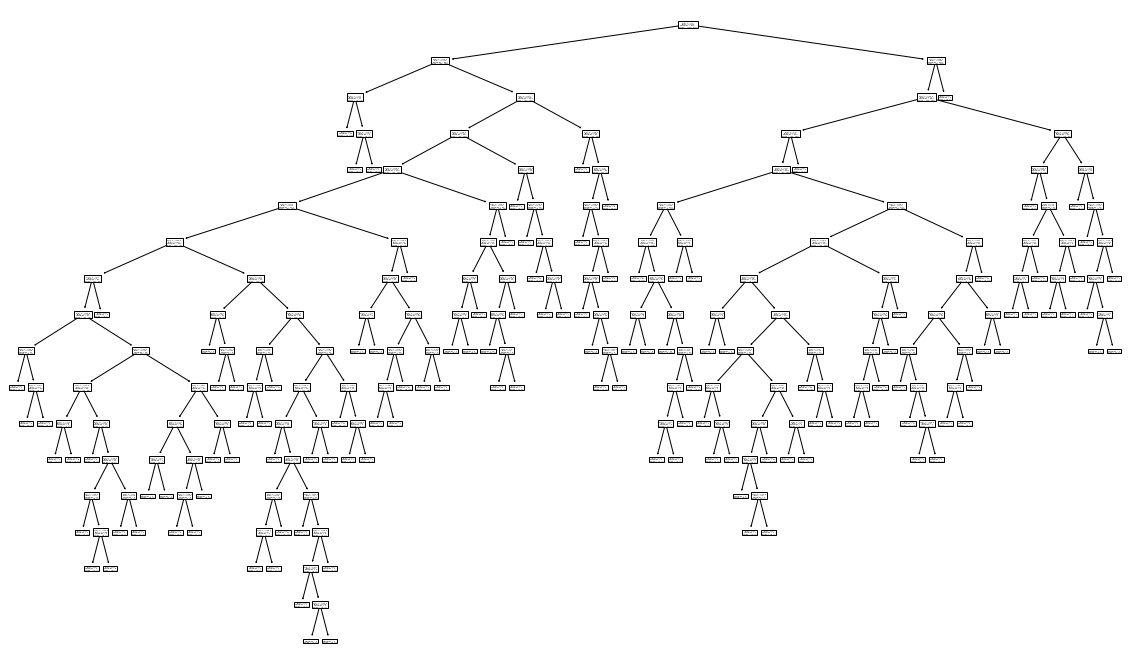

In [27]:
plt.figure(figsize=(20,12))
plot_tree(model);

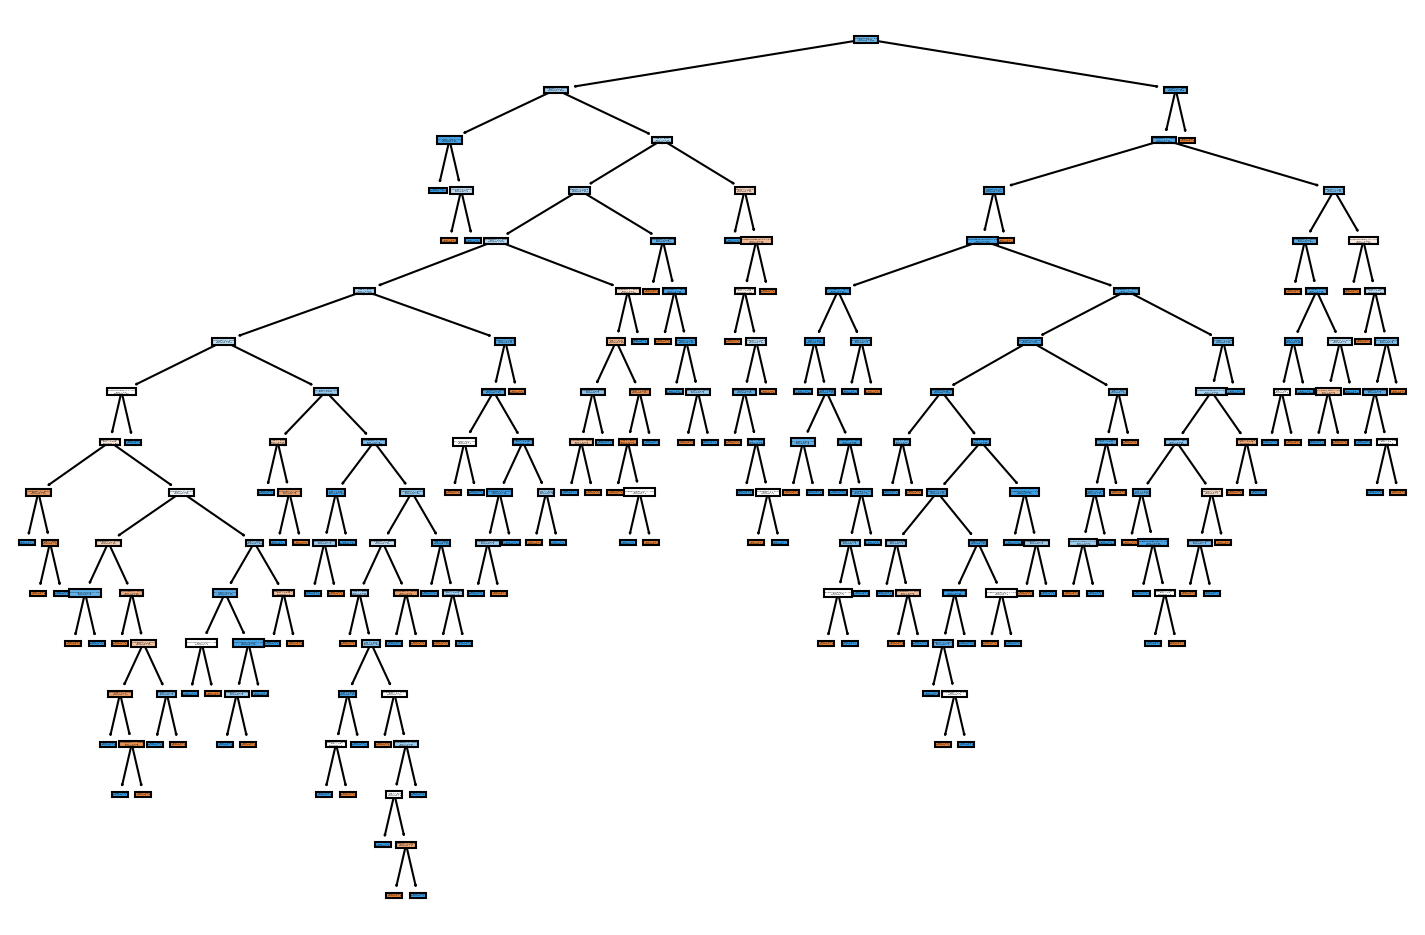

In [28]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(model,filled=True,feature_names=X.columns);